
# Member 2: Decision tree - Obesity label classification
### PROG2590 Final Group Project

## What is the purpose of this Jupyter notebook??
This code applies a Decision tree classifier to predict a person's obesity level from their lifestyle and health data. The dataset contains 2111 samples, has 16 different features, and has 7 target classes. 

## Why choose Decision trees?
- No scaling is needed: DTs are unaffected by feature scaling, unlike k-NN or SVM
- It handles mixed data: works with both continuous and encoded categorical features
- Interpretable: We can visualize the tree and see exactly what features it relied on.
- Fast: Low training and prediction time compared to other methods like Random Forest

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import time
import tracemalloc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from shared.evaluation.metrics import evaluate_model, print_evaluation_results


## 1. Load and explore the data

Before building anything, we should inspect the dataset. This will tell us how many rows and columns we are working with, what the data types of each column are, if there are any missing values, and how the target categories are distributed across the whole dataset. 

In [3]:

df = pd.read_csv("../../data/raw/ObesityDataSet_raw_and_data_sinthetic.csv")

print(f"Shape: {df.shape} ")
print(df.head())
print(df.dtypes)
print(df.isnull().sum())
print(df['NObeyesdad'].value_counts())
print(df.select_dtypes(include='object').columns.tolist())

Shape: (2111, 17) 
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Tra

C:\Users\matth\AppData\Local\Temp\ipykernel_2808\3298721448.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns.tolist())


The dataset has 2111 rows and 127 columns with no missing values present in any of the columns. 

The target column has 7 different obesity categories ranging from Insufficient Weight through to Obesity Type 3. The categories are pretty spread out through the samples; this means the model will have enough samples of each category to get good results.

Eight of the columns contain text values: Gender, family history, FAVC, CAEC,
SMOKE, SCC, CALC, and MTRANS. Machine learning models need numeric inputs, so we will need to convert these columns to numbers before the model can use them.



## 2. Preprocessing - LabelEncoder and the Train/Test Split

Raw data can't go into a machine learning model. So we need to do a few things.

*Encoding* - We used LabelEncoder to convert text columns into numbers. It scans each column, finds all the unique text values, and assigns each one to a number. An example being gender(Female: 0 | Male: 1). Every column is encoded similarly.

We encode the target column NObeyesdad separately. This is so we can use it later to decode predictions back into readable category names like "Obesity type 1" instead of showing the number, which someone might not know.

*Train/Test split* - The dataset gets divided into 2 different portions. 80% is used for training, from which the model will learn. The rest will be used in the test set, which the model will never see during training. This will let us properly see how the model performs on data it has never seen before.

Stratify ensures the proportion of each obesity category is preserved during both training and testing. So if 15% of the full dataset is Obesity type 1, both training and test will also be around 15%.

In [4]:
from shared.preprocessing.preprocess import prepare_data

file_path = "../../data/raw/ObesityDataSet_raw_and_data_sinthetic.csv"
data = prepare_data(file_path)

for col in data["X_train"].columns:
    if not pd.api.types.is_numeric_dtype(data["X_train"][col]):
        le = LabelEncoder()
        data["X_train"][col] = le.fit_transform(data["X_train"][col].astype(str))
        data["X_test"][col]  = le.transform(data["X_test"][col].astype(str))
        data["X"][col]       = le.fit_transform(data["X"][col].astype(str))

X_train        = data["X_train"]
X_test         = data["X_test"]
y_train        = data["y_train"]
y_test         = data["y_test"]
target_encoder = data["target_encoder"]
X              = data["X"]

feature_names = X.columns.tolist()

print("Training samples:", X_train.shape[0])
print("Test samples:",     X_test.shape[0])


Training samples: 1688
Test samples: 423


## 3. Baseline Model - Observing Overfitting

Before we tune anything, we want to build a Decision Tree without restrictions. This allows the tree to split continuously until every single leaf node contains one class; these are called pure leaves.

The reason we do this is to see what it looks like when the training data is memorized; this is called overfitting a model.

Overfitting happens when the model learns the data a little too well, rather than learning the general patterns that can be found in the data. An overfitted model will perform really well on training data but really badly on test data. The gap between the 2 accuracy scores is a visual example of overfitting. 

In [5]:
baseline = DecisionTreeClassifier(random_state=42)  
baseline.fit(X_train, y_train) 

train_preb_b = baseline.predict(X_train)
test_preb_b = baseline.predict(X_test)  

print(f"\nTrain Accuracy: {accuracy_score(train_preb_b, y_train):.3f}") 
print(f"Test Accuracy: {accuracy_score(test_preb_b, y_test):.3f}")
print(f"Tree depth: {baseline.get_depth()}")  



Train Accuracy: 1.000
Test Accuracy: 0.917
Tree depth: 11


The unrestricted tree achieved a perfect training accuracy, meaning it correctly classified every single training sample. The test accuracy is a good amount lower, which could show overfitting. The model memorized the training data rather than learning any patterns that generalize to the new data. 

The tree grew to a depth of 11 to achieve this perfect fit. We should now try to limit the tree from growing so deeply.

## 4. Hyperparameter Tuning - finding the best max_depth

The max_depth parameter controls how many levels deep the tree is allowed to grow. A tree that doesn't ask enough questions may underfit, where a tree with too much could overfit, as we saw above.

The goal is to find a depth where the test accuracy is at its highest. That is when the model learned enough real patterns without starting to memorize noise. This is the sweet spot.

Here, we test every depth from 2 to 10, along with one that has no limit, to record both train and test accuracy at each depth.


In [6]:
depths_to_try = [2, 3, 4, 5, 6, 7, 8, 9, 10, None]
results = []

for depth in depths_to_try:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    label = str(depth)if depth is not None else "None"
    results.append((label, train_acc, test_acc))
    print(f"max_depth={label:<6} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}") 

max_depth=2      | Train Acc: 0.5539 | Test Acc: 0.5390
max_depth=3      | Train Acc: 0.6487 | Test Acc: 0.6643
max_depth=4      | Train Acc: 0.7879 | Test Acc: 0.7754
max_depth=5      | Train Acc: 0.8507 | Test Acc: 0.8132
max_depth=6      | Train Acc: 0.9147 | Test Acc: 0.8723
max_depth=7      | Train Acc: 0.9301 | Test Acc: 0.8629
max_depth=8      | Train Acc: 0.9852 | Test Acc: 0.9078
max_depth=9      | Train Acc: 0.9941 | Test Acc: 0.9125
max_depth=10     | Train Acc: 0.9982 | Test Acc: 0.9102
max_depth=None   | Train Acc: 1.0000 | Test Acc: 0.9173


Reading through the results, the test accuracy does rise through depths 2 and 9, where it peaks at 0.9125. However, at depth 10, the test accuracy drops slightly, even though the train accuracy rises again. This is where the overfitting process starts

max_depth = 9 is therefore the best choice for us. The high training accuracy is nearly perfect but not 100%, and the gap between train and test is small at only 0.0816. This combination indicates the model has learned real patterns that hold on unseen data rather than memorizing the training set. 

## 5 Best Model - Training, Runtime, and Memory

We now train the final model using max_depth =. We also want to measure how long the training and prediction take, and how much memory the model uses while completing each step. 

Runtime and memory are really important when you are choosing a model. A model that takes hours to train or takes up gigabytes of memory to use may not be a good choice even if it has good results. Recording these numbers lets us compare the Decision tree fairly against the other models the group is evaluating.


In [7]:
best_depth = 9 
print("\n" + "="*45)
print(f"BEST MODEL: max_depth={best_depth}")
print("="*45)

start_train = time.time()  
classifier = DecisionTreeClassifier(max_depth=best_depth, random_state=42)  
classifier.fit(X_train, y_train)      
train_time = time.time() - start_train                                      

start_pred = time.time() 
test_pred = classifier.predict(X_test) 
pred_time = time.time() - start_pred

train_pred = classifier.predict(X_train) 

print(f"Training time: {train_time:.4f} seconds")
print(f"Prediction time: {pred_time:.4f}")

tracemalloc.start()
mem_clf = DecisionTreeClassifier(max_depth = best_depth, random_state=42) 
mem_clf.fit(X_train, y_train)
_, peak_train_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

tracemalloc.start()
_ = mem_clf.predict(X_test)
_, peak_pred_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Peak memory usage during training: {peak_train_mem / 1024:.2f} KB")  
print(f"Peak Memory when predicting: {peak_pred_mem / 1024:.2f}")


BEST MODEL: max_depth=9
Training time: 0.0074 seconds
Prediction time: 0.0013
Peak memory usage during training: 324.42 KB
Peak Memory when predicting: 82.66


## 6. Evaluation - Accuracy and Classification report

The Accuracy tells us the overall fraction of correct predictions, but does not paint the full picture, especially when we have 7 target categories. The classification report breaks down the performance per category using these three metrics:

*Precision* - of every prediction the model made for a category, what fraction was actually correct. Low precision means the model is producing false positives.

*Recall* - Of all the actual samples that belong to a category, what percentage of the samples did it successfully identify? Low recall means the model is missing real cases of that specific category, which causes it to produce false negatives.

*F1 score* - a number that balances precision and recall. Useful when you want one metric that captures both. A score of 1 is perfect, 0 is the worst.

*support* - the number of test samples that actually belong to each category. This tells us whether the scores are based on many samples os just a few of them.


In [8]:
train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test,  test_pred)

print("Train Accuracy:", round(train_acc, 3))
print("Test Accuracy:",  round(test_acc,  3))

results_eval = evaluate_model(classifier, X_test, y_test)
print_evaluation_results(results_eval)


Train Accuracy: 0.994
Test Accuracy: 0.913
Accuracy: 0.9125295508274232

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.87      0.92        54
           1       0.78      0.84      0.81        58
           2       0.92      0.94      0.93        70
           3       0.97      0.97      0.97        60
           4       1.00      0.98      0.99        65
           5       0.84      0.84      0.84        58
           6       0.91      0.91      0.91        58

    accuracy                           0.91       423
   macro avg       0.91      0.91      0.91       423
weighted avg       0.92      0.91      0.91       423


Confusion Matrix:
[[47  7  0  0  0  0  0]
 [ 1 49  0  0  0  8  0]
 [ 0  1 66  1  0  0  2]
 [ 0  0  2 58  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  6  0  0  0 49  3]
 [ 0  0  4  0  0  1 53]]


## 7. Feature Importance

After training, the decision tree stores a score for every input feature called its feature importance. This number represents how much that certain feature contributes to the model's decisions across all the splits in the tree.

Every value is between 0 and 1, where 0 means the feature was never used in the split at all/it was completely ignored. A value closer to 1 means the feature was basically relied on when making a decision, but the importance values always add up to 1.0 or 100%. This is useful because it tells us which input variables actually matter for predicting obesity and which ones are irrelevant. 

FEATURE IMPORTANCE
Gender: 0.1597
Age: 0.0437
Height: 0.2160
Weight: 0.4769
family_history_with_overweight: 0.0012
FAVC: 0.0220
FCVC: 0.0138
NCP: 0.0060
CAEC: 0.0126
SMOKE: 0.0014
CH2O: 0.0030
SCC: 0.0000
FAF: 0.0030
TUE: 0.0134
CALC: 0.0241
MTRANS: 0.0033

Saved: feature_importance.png


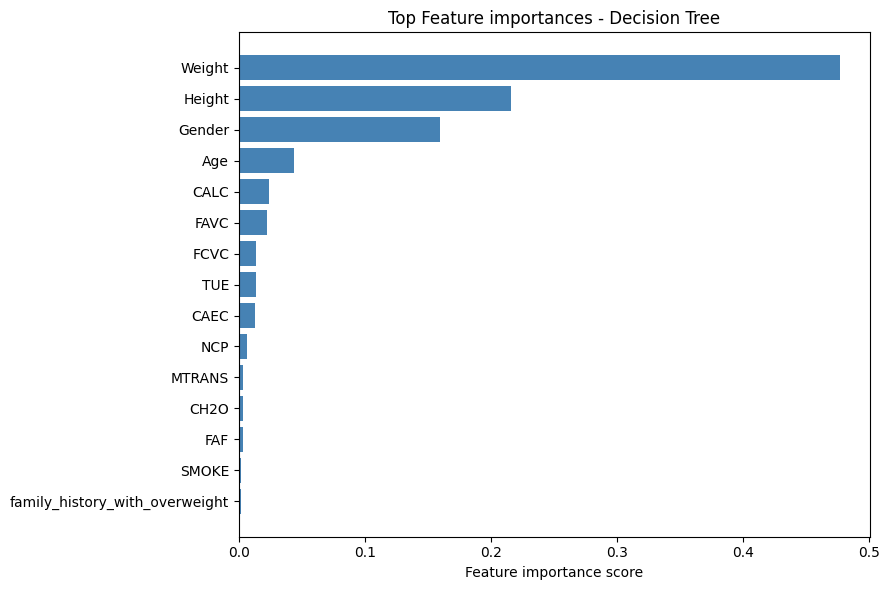

In [9]:
print("FEATURE IMPORTANCE")
for feature, importance in zip(X.columns, classifier.feature_importances_):
    print(f"{feature}: {importance:.4f}") 

importances = classifier.feature_importances_
indicies = np.argsort(importances)[::-1][:15] 
top_features = [feature_names[i] for i in indicies] 
top_values = importances[indicies] 


plt.figure(figsize=(9,6))
plt.barh(top_features[::-1], top_values[::-1], color='steelblue') 
plt.xlabel('Feature importance score')
plt.title('Top Feature importances - Decision Tree')
plt.tight_layout()
plt.savefig("../../member2/results/feature_importance.png", dpi=150)
print("\nSaved: feature_importance.png")
plt.show()

# 8. Tree Visualization

Now we can visualize the structure of the decision tree, including the number of questions it asks and the order in which they are asked. Each node in the tree will display the feature it is splitting on, the threshold value it uses, and the number of training samples that reach that node.

The color of each node indicates its majority class (the obesity category that most samples in that node belong to). Darker colors indicate purer nodes where most samples agree on the same class.

The reason we cut it down to showing only 3 levels is that a depth-9 tree would have 100s of nodes, making it nearly impossible to properly read and evaluate. 

Saved: tree_visualization.png


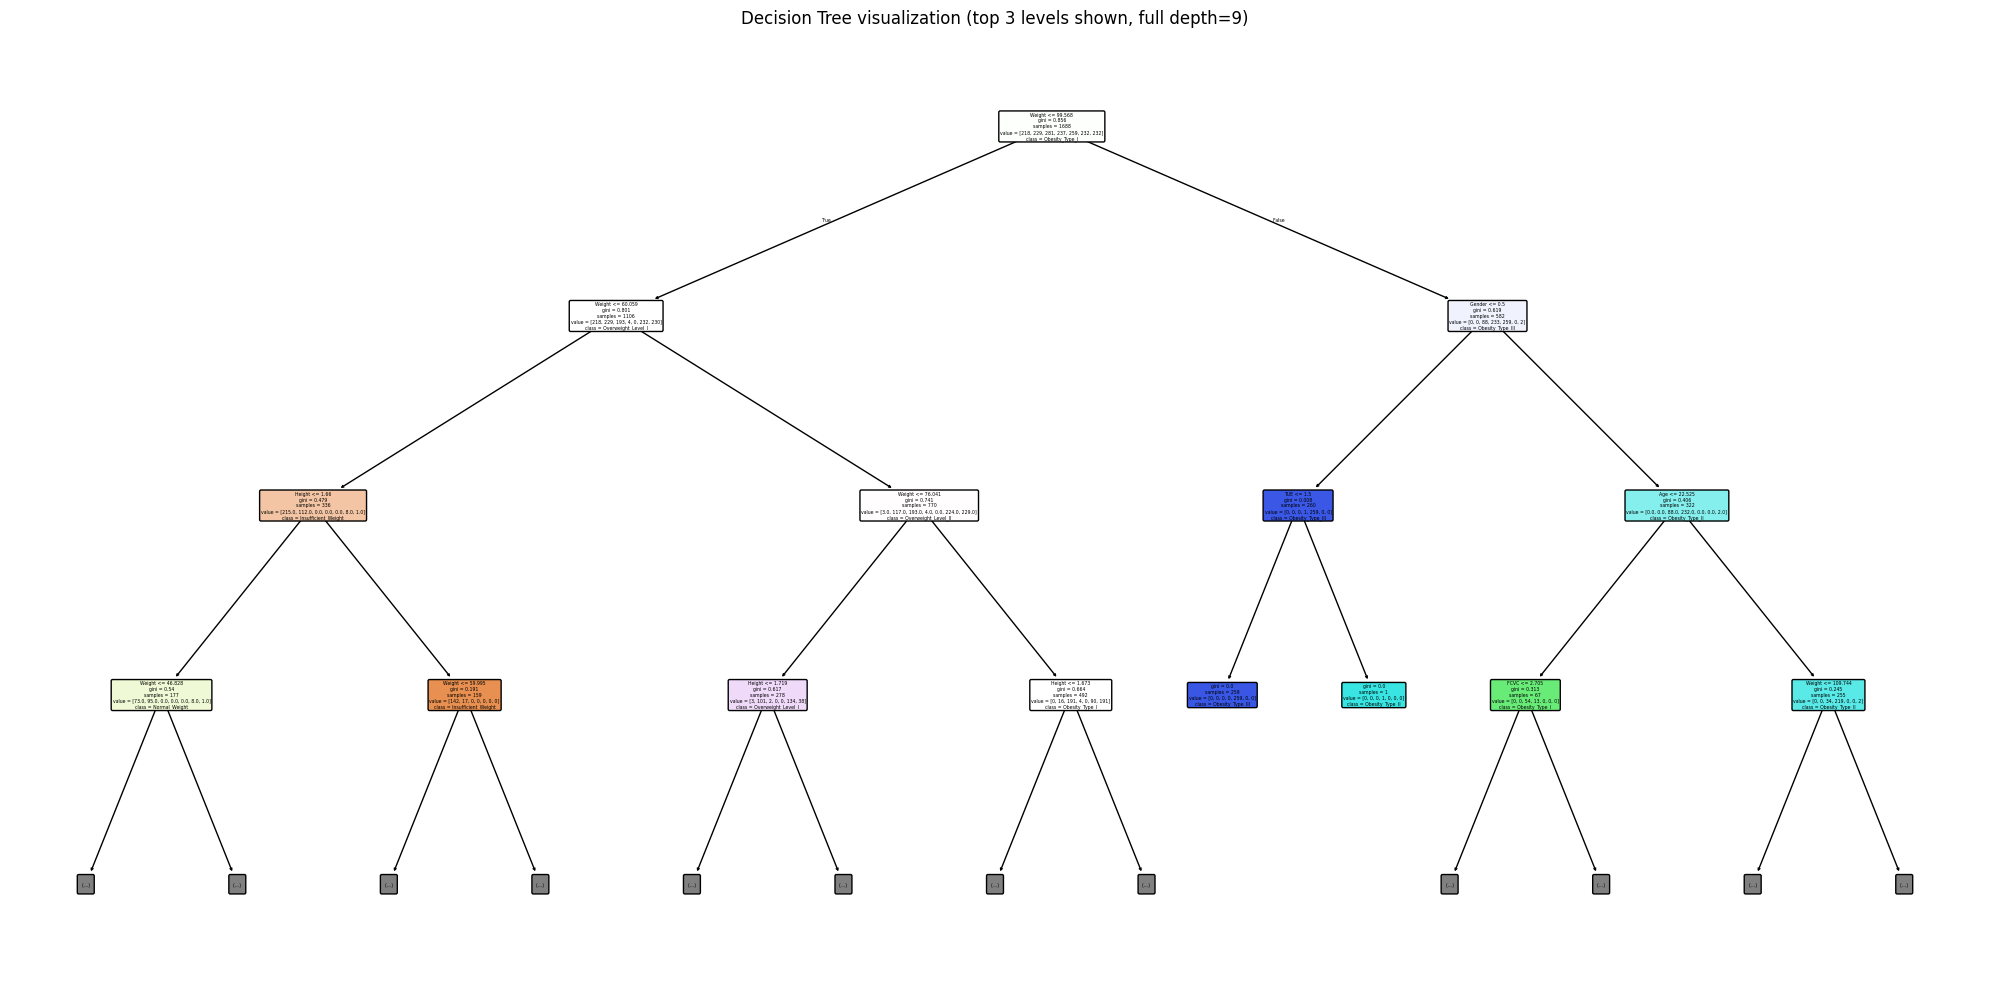

In [10]:
plt.figure(figsize=(20,10))
plot_tree(
    classifier,
    feature_names=feature_names, 
    class_names = target_encoder.classes_, 
    filled=True, 
    rounded=True, 
    max_depth = 3 
)
plt.title(f"Decision Tree visualization (top 3 levels shown, full depth={best_depth})")
plt.tight_layout()
plt.savefig("../../member2/results/tree_visualization.png", dpi=150)
print("Saved: tree_visualization.png")
plt.show()

## 9. Predict for a New Person

To confirm that the model works, we pass in a single new set of values and ask the model to predict which obesity category the person falls into. The model then returns a number, which we will decode back into actual category names using the target encoder we saved during preprocessing. 

In [11]:
new_person = pd.DataFrame([[1, 20, 1.67, 105, 0, 1, 2, 3, 2, 0, 2, 0, 1, 0, 1, 3]], columns=X.columns)

prediction = classifier.predict(new_person)

predicted_category = target_encoder.inverse_transform(prediction)

print("Predicted obesity category:", predicted_category[0])

Predicted obesity category: Obesity_Type_I


## Summary and Conclusions

Best max_depth: 9
Test Accuracy: 91.3%
Training time: 0.0082 seconds
Prediction time: 0.0013
Peak memory usage during training: 324.75 KB
Peak Memory when predicting: 82.66

The Decision tree classifier acheived 91.3% accuracy on the test set using a maximum depth of 9. The small gap between training accuracy of 99.4% and test accuracy indicates the model generalized well rather than simply memorizing the training data.

Weight and Height were by far the most important features, together accounting for close to 70% of all the decisions the model made. This makes sense given that obesity is directly linked with a person's physical measurements.

The model is pretty fast, where training completes in under 0.01 seconds, and predictions are nearly instant. Memory usage, as well, is minimal at under 400 KB during the training. 

The main issue with a single Decision Tree is that it can still overfit compared to ensemble methods. The Random Forest model builds on decision trees by combining many single trees to reduce the risk, at the cost of longer training time and a higher amount of memory used. 